### Coursework Question 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

#### Run the model

Firstly we will generate a synthetic dataset using the model stated in the question:

In [2]:
def generate_data(T):

    # Generate initial value of x randomly from N(0,1) and set seed for reproducibility
    rng1 = np.random.default_rng(1)
    x0 = stats.norm.rvs(random_state=rng1)

    # Generate values of noise for V and W
    rng2 = np.random.default_rng(2)
    v = stats.norm.rvs(loc=0,scale=np.sqrt(0.1),size=T,random_state=rng2)
    
    rng3 = np.random.default_rng(3)
    w = stats.norm.rvs(loc=0,scale=1,size=T+1,random_state=rng3)

    # Arrays to store hidden state (x) and observations (y)
    x = np.zeros(T+1)
    x[0] = x0
    y = np.zeros(T+1)
    y[0] = 1/20*x0**2 + w[0]

    # Recursively calculate hidden state and observations
    for i in range(1,T+1):
        x[i] = 1/2*x[i-1] + 25*x[i-1]/(1+x[i-1]**2) + 8*np.cos(1.2*i) + v[i-1]
        y[i] = 1/20*x[i]**2 + w[i]

    return x,y

In [3]:
hidden_state,y = generate_data(200)

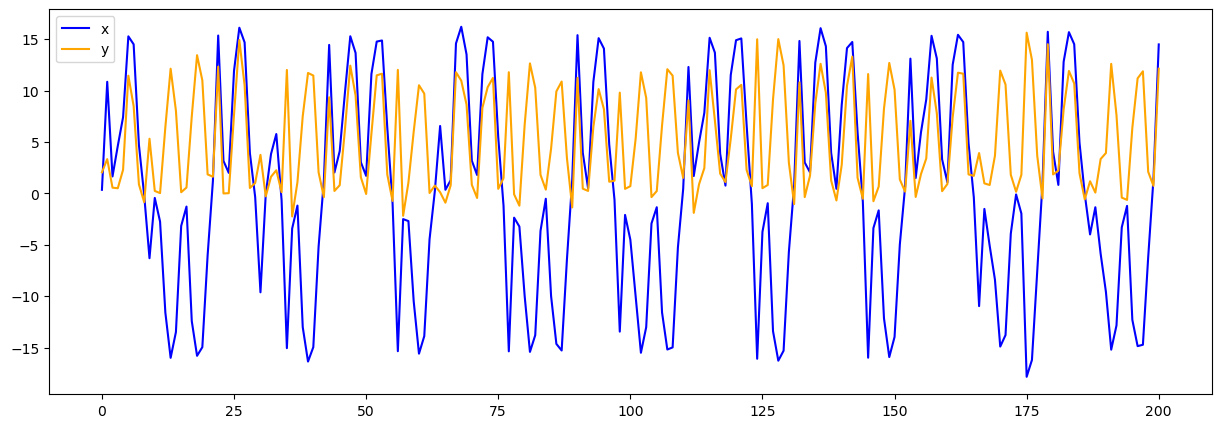

In [4]:
timesteps = np.arange(0,201)
plt.figure(figsize=(15,5))
plt.plot(timesteps,x,color="blue",label="x")
plt.plot(timesteps,y,color="orange",label="y")
plt.legend()

#### Code SIR Particle Filter

Firstly, we need to decide which importance density to use. To do this, check how flat the likelihood $p(y_n|x_n)$ is, as if the likelihood is relatively flat, we can use the Bootstrap Proposal, which is simpler.

The model is as follows:

$X_n = \frac{1}{2} X_{n-1} + \frac{25 X_{n-1}}{1+X_{n-1}^2} + 8cos(1.2n) + V_n$ with $V_n \sim N(0,0.1)$

$Y_n = \frac{1}{20} X_n^2 + W_n$ with $W_n \sim N(0,1)$

This means that the transition density and likelihood are:

$f(x_n|x_{n-1}) = \frac{1}{\sqrt{0.2\pi}} \exp(-\frac{1}{0.2}(x_n - (\frac{1}{2}x_{n-1} + \frac{25 x_{n-1}}{1+x_{n-1}^2} + 8cos(1.2n))^2)$

$g(y_n|x_n) = \frac{1}{\sqrt{2\pi}} \exp(-\frac{1}{2}(y_n - \frac{1}{20}x_n^2)^2)$

In [5]:
def g(x,y):
    val = 1/np.sqrt(2*np.pi)*np.exp(-1/2*(y-1/20*x**2)**2)
    return val

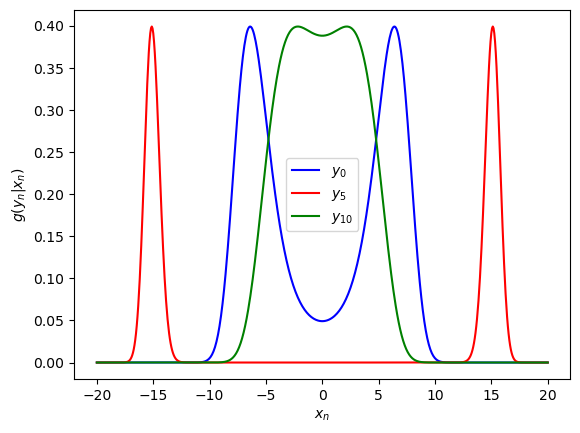

In [6]:
x = np.linspace(-20,20,num=600)
density1 = g(x,y[0])
density2 = g(x,y[5])
density3 = g(x,y[10])
plt.plot(x,density1,color="blue",label=r"$y_0$")
plt.plot(x,density2,color="red",label=r"$y_{5}$")
plt.plot(x,density3,color="green",label=r"$y_{10}$")
plt.xlabel(r"$x_n$")
plt.ylabel(r"$g(y_n|x_n)$")
plt.legend()

Unfortunately, the likelihoods look quite informative, so the Bootstrap proposal is not likely to work well. Therefore we need to calculate the linearised version of the optimal proposal.

In [7]:
print(y[0])

2.046890543075436


In [8]:
print(y[5])

11.441441364296404


In [9]:
print(y[10])

0.23566440527652635


To implement the SIR filter, we need to write functions for $f(x_n|x_{n-1})$, $g(y_n|x_n)$, $q(x_n|y_n,x_{n-1})$ and the resampling step. We will use multinomial resampling. To avoid numerical stability issues, we need to work with the log densities instead of the densities themselves.

Also, it turns out that if $X_0 \sim N(0,1)$, the optimal proposal $q(x_0|y_0)$ is also $N(0,1)$, so these cancel out in the weight calculations.

In [87]:
def log_f(x,x_prev,n):

    mean = 1/2*x_prev + 25*x_prev/(1+x_prev**2) + 8*np.cos(1.2*n)
    var = 0.1
    
    val = -1/2*np.log(2*np.pi*var) - 1/(2*var)*(x-mean)**2
    return val

In [95]:
def log_g(x,y):

    mean = 1/20*x**2
    var = 1
    
    val = -1/2*np.log(2*np.pi*var) - 1/(2*var)*(x-mean)**2
    return val

In [44]:
def prop_mean_var(y,x_prev,n):

    # See equations for mean and variance of optimal propsal in notes
    psi = 1/2*x_prev + 25*x_prev/(1+x_prev**2) + 8*np.cos(1.2*n)
    S = 1/(10 + 1/100*psi**2)
    m = S*(10*psi + 1/10*psi*(y-1/20*psi+1/10*psi**2))

    return m,S

In [89]:
def log_q(x,m,S):

    val = -1/2*np.log(2*np.pi*S) - 1/(2*S)*(x-m)**2
    return val

In [231]:
def resample(omega, X, rng):

    # Number of particles
    N = len(X[:,0])

    # Sample offspring from a multinomial distribution with probabilities equal to weights omega
    copies = stats.multinomial.rvs(N,omega,random_state=rng)

    new_X = np.zeros(X.shape)

    # Make new particles by copying each old particle a number of times equal to 'copies'
    k = 0
    for i in range(N):
        for _ in range(copies[i]):
            new_X[k,:] = X[i,:]
            k = k+1

    return new_X

In [249]:
def SIR(y,N,max_n):

    # Set array to store particles for max_n iterations
    X = np.zeros((N,max_n+1))

    # TIME 0
    # Sample from initial proposal (N(0,1)), calculate weights and normalise
    rng = np.random.default_rng(seed=0)
    X[:,0] = stats.norm.rvs(size=N,random_state=rng)
    # In the initial case, the transition density and proposal cancel out, leaving omega = g(y0|x0)
    log_omega = log_g(X[:,0],y[0])
    max_val = max(log_omega)
    omega = np.exp(log_omega-max_val)/sum(np.exp(log_omega-max_val))
    X = resample(omega,X,rng)

    # TIME n>0
    for n in range(1,max_n+1):
        
        m,S = prop_mean_var(y[0],X[:,n-1],n)
        rng = np.random.default_rng(seed=n)
        X[:,n] = stats.norm.rvs(loc=m,scale=np.sqrt(S),size=N,random_state=rng)
        
        # For n>0, omega = f*g/proposal
        # Need to work with logs to avoid numerical stability issues
        log_omega = log_f(X[:,n],X[:,n-1],n) + log_g(X[:,n],y[n]) - log_q(X[:,n],m,S)
        # Use exp-normalise trick
        max_val = max(log_omega)
        omega = np.exp(log_omega-max_val)/sum(np.exp(log_omega-max_val))
        rng2 = np.random.default_rng(seed=3*n)
        X = resample(omega,X,rng2)

    return X

WARNING: The results seem quite sensitive to the seed used for the multinomial distribution. Is this an issue with the way the algorithm has been coded?

In [250]:
X = SIR(y,500,max_n=200)

Index starts from 0 so n=199 is the 200th element:

(array([ 1.,  2.,  0.,  7.,  0.,  2.,  6.,  2.,  4.,  2., 10.,  3.,  9.,
        12.,  3., 14.,  7.,  9.,  8., 22., 18., 24., 19., 19., 19., 23.,
        21., 32., 21., 19., 14., 18., 18., 13.,  5., 14.,  9., 12., 10.,
        11., 11.,  3.,  6.,  3.,  0.,  2.,  2.,  6.,  0.,  5.]),
 array([11.84131505, 11.8813508 , 11.92138654, 11.96142228, 12.00145803,
        12.04149377, 12.08152951, 12.12156525, 12.161601  , 12.20163674,
        12.24167248, 12.28170822, 12.32174397, 12.36177971, 12.40181545,
        12.44185119, 12.48188694, 12.52192268, 12.56195842, 12.60199417,
        12.64202991, 12.68206565, 12.72210139, 12.76213714, 12.80217288,
        12.84220862, 12.88224436, 12.92228011, 12.96231585, 13.00235159,
        13.04238734, 13.08242308, 13.12245882, 13.16249456, 13.20253031,
        13.24256605, 13.28260179, 13.32263753, 13.36267328, 13.40270902,
        13.44274476, 13.4827805 , 13.52281625, 13.56285199, 13.60288773,
        13.64292348, 13.68295922, 13.72299496, 13.7630307 ,

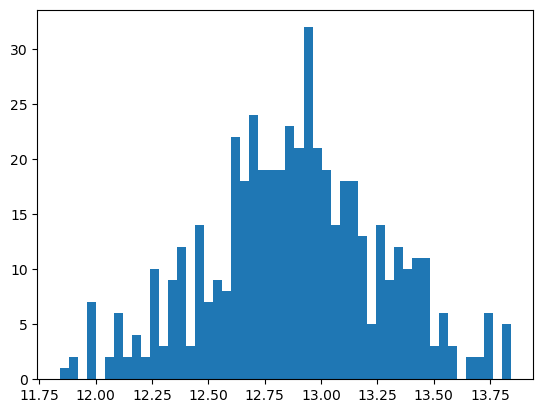

In [257]:
plt.hist(X[:,200],bins=50)

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0., 500.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.]),
 array([-0.23095464, -0.21095464, -0.19095464, -0.17095464, -0.15095464,
        -0.13095464, -0.11095464, -0.09095464, -0.07095464, -0.05095464,
        -0.03095464, -0.01095464,  0.00904536,  0.02904536,  0.04904536,
         0.06904536,  0.08904536,  0.10904536,  0.12904536,  0.14904536,
         0.16904536,  0.18904536,  0.20904536,  0.22904536,  0.24904536,
         0.26904536,  0.28904536,  0.30904536,  0.32904536,  0.34904536,
         0.36904536,  0.38904536,  0.40904536,  0.42904536,  0.44904536,
         0.46904536,  0.48904536,  0.50904536,  0.52904536,  0.54904536,
         0.56904536,  0.58904536,  0.60904536,  0.62904536,  0.64904536,
 

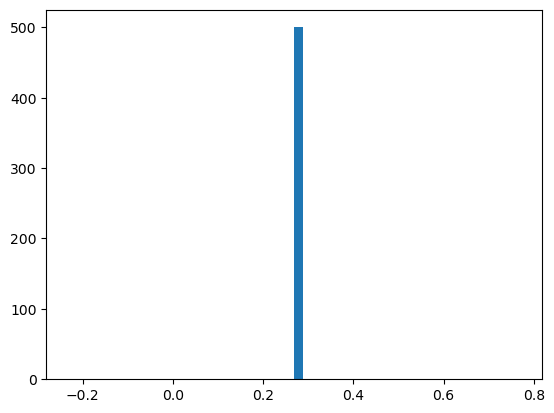

In [258]:
plt.hist(X[:,149],bins=50)

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0., 500.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.]),
 array([18.52201739, 18.54201739, 18.56201739, 18.58201739, 18.60201739,
        18.62201739, 18.64201739, 18.66201739, 18.68201739, 18.70201739,
        18.72201739, 18.74201739, 18.76201739, 18.78201739, 18.80201739,
        18.82201739, 18.84201739, 18.86201739, 18.88201739, 18.90201739,
        18.92201739, 18.94201739, 18.96201739, 18.98201739, 19.00201739,
        19.02201739, 19.04201739, 19.06201739, 19.08201739, 19.10201739,
        19.12201739, 19.14201739, 19.16201739, 19.18201739, 19.20201739,
        19.22201739, 19.24201739, 19.26201739, 19.28201739, 19.30201739,
        19.32201739, 19.34201739, 19.36201739, 19.38201739, 19.40201739,
 

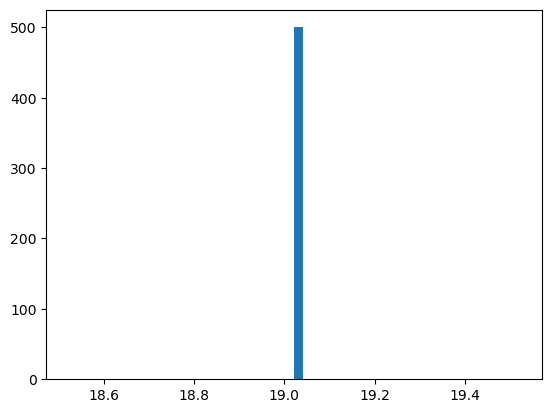

In [259]:
plt.hist(X[:,99],bins=50)

The plots above show $p(x_n|y_{0:T})$, ie the distribution after running the entire filter.

This is an example of (quite severe) path degeneracy:

- For $n=199$, we get a broad distribution of values, due to resampling particles and allowing them to evolve.
- For $n=150$ and before, the distribution is concentrated around one specific value. This is because, due to resampling where particles with low weights are discarded, pretty much all of the surviving particles have the same ancestor. This leads to the distribution essentially being just a single value.

Plot particle paths and compare to the true hidden state:

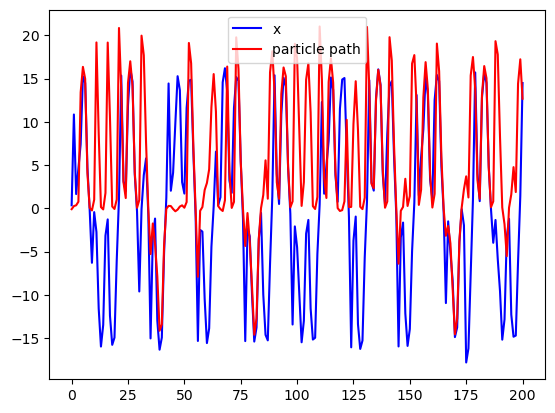

In [260]:
plt.plot(timesteps,hidden_state,color="blue",label="x")
plt.plot(timesteps,X[0,:],color="red",label="particle path")
plt.legend()

Some observations:

- The red graph matches the blue graph fairly well in some places and not well at all in other places.
- Notably, when the blue graph has negative spikes, the red graph has positive spikes in the opposite direction. This is probably because the model only sees the observed state $y_n$, which due to squaring has positive values at all of these spikes. This means there will be some density on both negative values and positive values, but only the particle which was in the positive region might survive in the long term.

To get $p(x_n|y_{0:n})$, we need to collect the particles after iteration $n$ and plot those, rather than after the entire filter has been run. To do this for the stated values of $n$, we need to run the filter for each value of $n$ we want to plot and use the final hidden state distribution.

In [261]:
x_dist_150 = SIR(y,500,max_n=150)

(array([ 2.,  2.,  0.,  0.,  4.,  0., 19.,  0.,  0., 27., 53., 53., 36.,
        32.,  0., 31., 62.,  0., 32.,  0.,  0.,  0., 23., 29., 23., 17.,
        14.,  0.,  9.,  0.,  7.,  7.,  6.,  4.,  0.,  4.,  0.,  0.,  0.,
         0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  3.]),
 array([-2.11049516, -1.96874727, -1.82699939, -1.68525151, -1.54350362,
        -1.40175574, -1.26000785, -1.11825997, -0.97651209, -0.8347642 ,
        -0.69301632, -0.55126843, -0.40952055, -0.26777267, -0.12602478,
         0.0157231 ,  0.15747099,  0.29921887,  0.44096675,  0.58271464,
         0.72446252,  0.86621041,  1.00795829,  1.14970617,  1.29145406,
         1.43320194,  1.57494983,  1.71669771,  1.85844559,  2.00019348,
         2.14194136,  2.28368925,  2.42543713,  2.56718501,  2.7089329 ,
         2.85068078,  2.99242867,  3.13417655,  3.27592443,  3.41767232,
         3.5594202 ,  3.70116809,  3.84291597,  3.98466385,  4.12641174,
         4.26815962,  4.40990751,  4.55165539,  4.69340327,

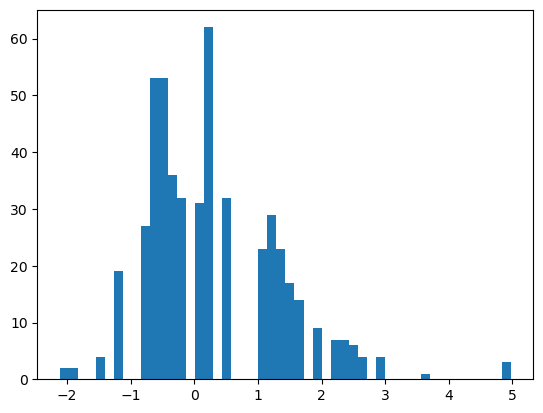

In [263]:
plt.hist(x_dist_150[:,-1],bins=50)

In [279]:
x_dist_100 = SIR(y,500,100)

(array([ 1.,  2.,  3., 13.,  4., 17.,  9., 16., 22., 27., 38., 46., 34.,
        30., 31., 29., 21., 33., 15., 11.,  9., 14.,  5., 19.,  8.,  3.,
         8.,  8.,  0.,  0.,  0.,  7.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  8.,  0.,  0.,  0.,  0.,  5.,  0.,  0.,  0.,  4.]),
 array([16.82069434, 16.8869418 , 16.95318925, 17.01943671, 17.08568417,
        17.15193163, 17.21817908, 17.28442654, 17.350674  , 17.41692146,
        17.48316891, 17.54941637, 17.61566383, 17.68191129, 17.74815874,
        17.8144062 , 17.88065366, 17.94690112, 18.01314857, 18.07939603,
        18.14564349, 18.21189095, 18.2781384 , 18.34438586, 18.41063332,
        18.47688078, 18.54312823, 18.60937569, 18.67562315, 18.74187061,
        18.80811806, 18.87436552, 18.94061298, 19.00686044, 19.07310789,
        19.13935535, 19.20560281, 19.27185027, 19.33809772, 19.40434518,
        19.47059264, 19.5368401 , 19.60308755, 19.66933501, 19.73558247,
        19.80182993, 19.86807738, 19.93432484, 20.0005723 ,

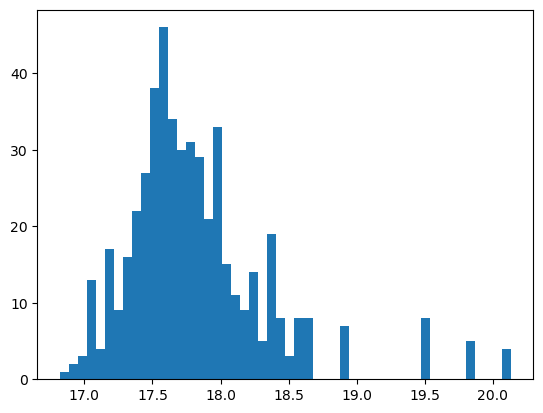

In [280]:
plt.hist(x_dist_100[:,-1],bins=50)